# Gravity as First Implementation Output — Metric-Like Route

The scalar-tail proxy did its job: it exposed a hard sign problem.

For the additive potential
$$
\Phi(r)=-\frac{\mu}{r}+\frac{A}{r^2},
$$
the perihelion shift is
$$
\Delta\varpi \approx -\,\frac{2\pi A}{\mu a(1-e^2)},
$$
so $A>0$ gives **retrograde** precession.

That means the current positive scalar tail is too naive if the target anomaly is prograde.

The next exact step is therefore the geometric one:

$$
\boxed{
\text{what if the first observable correction is metric-like rather than a bare additive scalar potential?}
}
$$

This notebook derives the generic metric-like precession law and compares its sign structure to the scalar-tail route.


## 1. Generic metric-like orbit equation

A broad class of relativistic / geometric corrections can be written in orbit form as

$$
u'' + u = k + \beta u^2,
$$

where

- $u(\varphi)=1/r(\varphi)$,
- $k=\mu/h^2 = 1/p$ for the underlying Kepler problem,
- $\beta$ is the leading metric-like correction coefficient.

For Schwarzschild GR,

$$
\beta_{\text{GR}} = \frac{3\mu}{c^2},
$$

so the equation is

$$
u''+u = \frac{\mu}{h^2} + \frac{3\mu}{c^2}u^2.
$$

The key point is that this is **not** the same sign structure as the scalar additive $A/r^2$ route.


## 2. First-order precession law

Take the unperturbed Kepler orbit

$$
u_0(\varphi)=k\left(1+e\cos\varphi\right).
$$

Substitute into the perturbation:

$$
\beta u_0^2
=
\beta k^2\left(1 + 2e\cos\varphi + e^2\cos^2\varphi\right).
$$

The resonant term is the $\cos\varphi$ piece:

$$
2\beta k^2 e \cos\varphi.
$$

Now allow the orbital phase to drift slightly:

$$
u(\varphi)\approx k\left[1+e\cos((1-\epsilon)\varphi)\right].
$$

To first order in $\epsilon$,

$$
u''+u \approx k + 2k e \epsilon \cos\varphi.
$$

Matching the resonant coefficients gives

$$
2k e \epsilon = 2\beta k^2 e
\quad\Rightarrow\quad
\boxed{
\epsilon = \beta k.
}
$$

Therefore the perihelion advance per orbit is

$$
\boxed{
\Delta\varpi \approx 2\pi \beta k
= \frac{2\pi \beta \mu}{h^2}
= \frac{2\pi \beta}{a(1-e^2)}.
}
$$

So the sign rule is now:

- $\beta>0$ gives **prograde** precession,
- $\beta<0$ gives **retrograde** precession.

This is the opposite sign logic from the additive scalar-tail route.


## 3. GR as a special case

For Schwarzschild GR,

$$
\beta = \frac{3\mu}{c^2}.
$$

Substituting gives

$$
\boxed{
\Delta\varpi_{\text{GR}}
\approx
\frac{6\pi\mu}{a(1-e^2)c^2}.
}
$$

So the geometric route naturally produces a **positive** (prograde) correction with a positive coefficient.

This is exactly the sign behavior the scalar-tail proxy failed to reproduce.


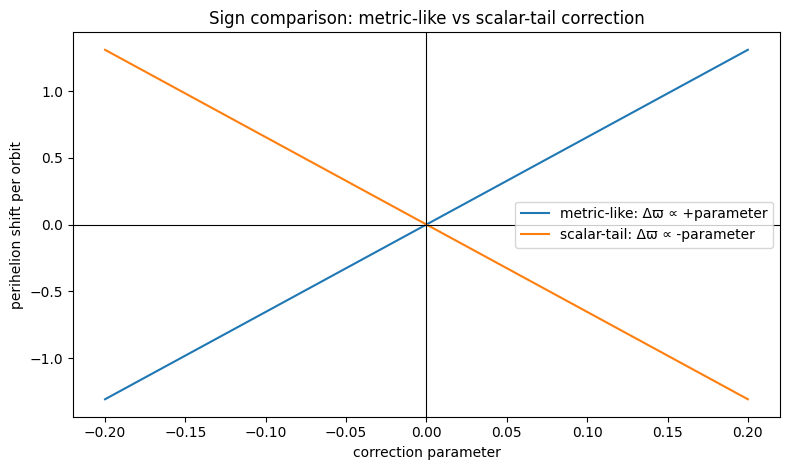

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def delta_varpi_metric(beta, a=1.0, e=0.2):
    return 2*np.pi*beta/(a*(1-e**2))

def delta_varpi_scalar(A, mu=1.0, a=1.0, e=0.2):
    return -2*np.pi*A/(mu*a*(1-e**2))

params = np.linspace(-0.2, 0.2, 401)
metric_vals = delta_varpi_metric(params, a=1.0, e=0.2)
scalar_vals = delta_varpi_scalar(params, mu=1.0, a=1.0, e=0.2)

plt.figure(figsize=(8,4.8))
plt.plot(params, metric_vals, label="metric-like: Δϖ ∝ +parameter")
plt.plot(params, scalar_vals, label="scalar-tail: Δϖ ∝ -parameter")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("correction parameter")
plt.ylabel("perihelion shift per orbit")
plt.title("Sign comparison: metric-like vs scalar-tail correction")
plt.legend()
plt.tight_layout()
plt.show()


The sign contrast is now explicit:

$$
\boxed{
\text{scalar-tail route: positive parameter } \Rightarrow \text{ retrograde}
}
$$

$$
\boxed{
\text{metric-like route: positive parameter } \Rightarrow \text{ prograde}
}
$$

So if the gravity-as-output branch wants to preserve a positive coupling interpretation while reproducing a prograde anomaly, the metric-like route is the natural place to continue.


## 4. Compactness scaling

Both routes still concentrate the signal in compact and eccentric systems.

For the metric-like correction,

$$
\boxed{
\Delta\varpi \propto \frac{1}{a(1-e^2)}.
}
$$

So the target regime remains:

- compact orbits,
- eccentric orbits,
- dense-source systems.

That means the previous regime choice still stands even though the sign logic changes.


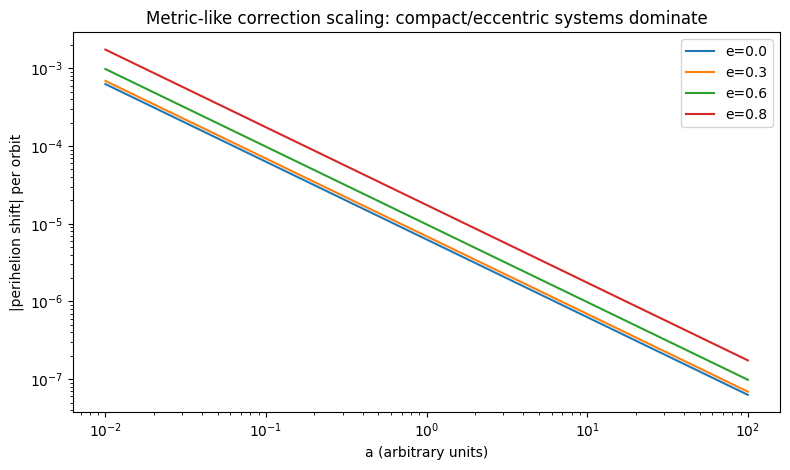

In [2]:

a_vals = np.logspace(-2, 2, 400)
e_list = [0.0, 0.3, 0.6, 0.8]
beta = 1e-6

plt.figure(figsize=(8,4.8))
for e in e_list:
    dvarpi = delta_varpi_metric(beta, a=a_vals, e=e)
    plt.loglog(a_vals, np.abs(dvarpi), label=f"e={e}")
plt.xlabel("a (arbitrary units)")
plt.ylabel("|perihelion shift| per orbit")
plt.title("Metric-like correction scaling: compact/eccentric systems dominate")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Runtime interpretation

This is the key architectural update.

The full stack is now best read as

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
\rho_\Gamma
\to
v_{\mathrm{eff}}
\to
\kappa
\to
\text{effective metric correction}
\to
\Delta\varpi,\ \text{redshift},\ \text{lensing}.
}
$$

So the first implementation output of the runtime may well be **geometric in the metric sense**, not just a scalar additive exterior potential.

That is consistent with the whole logic of the branch:

- gravity is not primitive,
- gravity is not a peer to the later force precedents,
- gravity is the first world-scale implementation of the runtime,
- therefore its first observable correction should plausibly be geometric.


## 6. What this notebook actually proves

This notebook does not prove the full gravity theory.

It proves something narrower but very important:

1. the scalar-tail proxy gives the wrong sign for a positive coupling,
2. the generic metric-like correction gives the right sign for a positive coefficient,
3. therefore the gravity-as-output branch should continue on the **metric-like route**, not the naive scalar additive route.

That is the first real branch decision produced by the code.


## 7. Next exact move

The next continuation is now clear:

1. write the first effective metric ansatz sourced by $\rho_\Gamma$,
2. derive the corresponding weak-field observables,
3. and test whether the same metric coefficient also gives the correct signs for:
   - perihelion advance,
   - clock shift,
   - and light bending.

That is the right boundary now.
